# k-Nearest Neighbors: nichtparametrische Klassifikation von Grund auf

**Notebook 03 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Im Gegensatz zu den parametrischen Modellen der Notebooks 01–02 trifft k-Nearest
Neighbors (k-NN) keine funktionale Annahme über $P(y\mid\mathbf{x})$, sondern schätzt
sie lokal aus den $k$ nächsten Trainingspunkten. Dieses Notebook leitet den
Bayes-Zusammenhang von k-NN her, implementiert den Algorithmus vollständig mit
`NumPy`, untersucht den Bias-Varianz-Tradeoff über $k$ mittels $k$-facher
Kreuzvalidierung, demonstriert den *Fluch der Dimensionalität* an einer kontrollierten
Simulation und validiert die Implementierung gegen `scikit-learn`.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. k-NN als lokale Schätzung von $P(y\mid\mathbf{x})$ begründen und vom Bayes-optimalen
   Klassifikator abgrenzen,
2. euklidische und Manhattan-Distanz unterscheiden und ihre Sensitivität gegenüber
   Merkmalsskalierung einschätzen,
3. den Bias-Varianz-Tradeoff über $k$ mittels Kreuzvalidierung quantitativ bestimmen,
4. den Fluch der Dimensionalität an konkreten Zahlen nachvollziehen,
5. die Rechenkomplexität von k-NN zur Trainings- und Vorhersagezeit anderer Modelle in
   Beziehung setzen.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Datengrundlage](#3)
4. [Implementierung](#4)
5. [Empirische Analyse](#5)
6. [Diskussion und Grenzen](#6)
7. [Übungsaufgaben](#7)
8. [Literatur](#8)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Der Bayes-optimale Klassifikator

Wüsste man $P(y=c\mid\mathbf{x})$ exakt, wäre die optimale Entscheidungsregel
(**Bayes-Klassifikator**) $\hat y(\mathbf{x}) = \arg\max_c P(y=c\mid\mathbf{x})$; ihre
Fehlerrate (**Bayes-Fehler**) ist die niedrigste, die *irgendein* Klassifikator auf
diesem Problem erreichen kann. In der Praxis ist $P(y\mid\mathbf{x})$ unbekannt und muss
aus Daten geschätzt werden.

### 1.2 k-NN als lokale Wahrscheinlichkeitsschätzung

k-NN approximiert $P(y=c\mid\mathbf{x})$ durch den Anteil der Klasse $c$ unter den $k$
nächsten Trainingspunkten zu $\mathbf{x}$:

$$
\hat P(y=c\mid\mathbf{x}) = \frac{1}{k}\sum_{i\in N_k(\mathbf{x})} \mathbb{1}[y_i = c],
\qquad
\hat y(\mathbf{x}) = \arg\max_c \hat P(y=c\mid\mathbf{x}),
$$

wobei $N_k(\mathbf{x})$ die Indexmenge der $k$ nächsten Nachbarn bezüglich einer
Distanzfunktion $d(\cdot,\cdot)$ ist. Für $k\to\infty$ und $k/n\to 0$ konvergiert
$\hat P$ gegen $P(y\mid\mathbf{x})$ (Cover & Hart, 1967) — k-NN ist also
**konsistent**, aber nur asymptotisch; bei endlichem $n$ bestimmt $k$ maßgeblich den
Bias-Varianz-Tradeoff (Notebook 00, Abschnitt 5): kleines $k$ (insbesondere $k=1$) hat
niedrigen Bias und hohe Varianz, großes $k$ das Gegenteil — im Extremfall $k=n$ sagt
das Modell für jeden Punkt die globale Mehrheitsklasse voraus (maximaler Bias, keine
Varianz).

### 1.3 Distanzmetriken

Für $\mathbf{x},\mathbf{z}\in\mathbb{R}^p$ sind die euklidische und die
Manhattan-Distanz Spezialfälle der Minkowski-Distanz
$d_r(\mathbf{x},\mathbf{z}) = \bigl(\sum_j|x_j-z_j|^r\bigr)^{1/r}$ für $r=2$ bzw. $r=1$.
Da die Distanz alle Merkmale gleich gewichtet, ist k-NN **skalensensitiv**: Ein Merkmal
mit größerem numerischem Wertebereich dominiert die Distanzberechnung, sofern nicht
standardisiert wird.

### 1.4 Rechenaufwand

k-NN ist ein **lazy learner**: `fit` speichert nur die Trainingsdaten,
$\mathcal{O}(1)$. Jede Vorhersage kostet naiv $\mathcal{O}(np)$ (Distanz zu allen $n$
Punkten in $p$ Dimensionen) — im Gegensatz zu den parametrischen Modellen der
Notebooks 01–02, bei denen der gesamte Trainingsaufwand einmalig anfällt und die
Vorhersage $\mathcal{O}(p)$ kostet. Für große $n$ existieren Baumstrukturen (kd-Bäume,
Ball-Trees), die die Vorhersagekosten auf $\mathcal{O}(\log n \cdot p)$ senken
(`scikit-learn` nutzt diese standardmäßig).

In [1]:
from __future__ import annotations

import sys
from collections import Counter

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Datengrundlage

Als Hauptbeispiel dient ein Datensatz mit gekrümmter, nicht-linearer Klassengrenze
(Halbmonde) — genau der Fall, an dem die logistische Regression in Notebook 02,
Abschnitt 6.2 scheiterte. k-NN benötigt keine Annahme über die Form der Grenze.

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"n_train={len(X_train)}, n_test={len(X_test)}")

n_train=210, n_test=90


<a id="4"></a>
## 4 Implementierung

In [3]:
class KNearestNeighbors:
    """k-Nearest-Neighbors-Klassifikator (lazy learner).

    Parameters
    ----------
    k : int, default=5
        Anzahl der zu betrachtenden Nachbarn.
    metric : {"euclidean", "manhattan"}, default="euclidean"
        Distanzmetrik (Abschnitt 1.3).

    Attributes
    ----------
    X_train_, y_train_ : ndarray
        Gespeicherte Trainingsdaten (fit fuehrt keine Berechnung aus).
    """

    def __init__(self, k: int = 5, metric: str = "euclidean") -> None:
        if k < 1:
            raise ValueError("k muss mindestens 1 sein")
        if metric not in ("euclidean", "manhattan"):
            raise ValueError("metric muss 'euclidean' oder 'manhattan' sein")
        self.k = k
        self.metric = metric
        self.X_train_: np.ndarray | None = None
        self.y_train_: np.ndarray | None = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "KNearestNeighbors":
        """Speichert die Trainingsdaten. O(1) -- kein eigentliches Training."""
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y)
        return self

    def _distances(self, x: np.ndarray) -> np.ndarray:
        """Vektorisierte Distanz von x zu allen gespeicherten Trainingspunkten."""
        diff = self.X_train_ - x
        if self.metric == "euclidean":
            return np.sqrt(np.sum(diff**2, axis=1))
        return np.sum(np.abs(diff), axis=1)

    def _neighbor_labels(self, x: np.ndarray) -> np.ndarray:
        distances = self._distances(x)
        k_idx = np.argpartition(distances, min(self.k, len(distances) - 1))[: self.k]
        return self.y_train_[k_idx]

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Sagt die Mehrheitsklasse unter den k naechsten Nachbarn vorher."""
        if self.X_train_ is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        preds = np.empty(len(X), dtype=self.y_train_.dtype)
        for i, x in enumerate(X):
            labels = self._neighbor_labels(x)
            preds[i] = Counter(labels).most_common(1)[0][0]
        return preds

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Gibt den Stimmenanteil jeder Klasse unter den k Nachbarn zurueck."""
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        classes = np.unique(self.y_train_)
        proba = np.zeros((len(X), len(classes)))
        for i, x in enumerate(X):
            labels = self._neighbor_labels(x)
            for j, cls in enumerate(classes):
                proba[i, j] = np.mean(labels == cls)
        return proba

<a id="5"></a>
## 5 Empirische Analyse

### 5.1 Entscheidungsgrenzen für verschiedene $k$

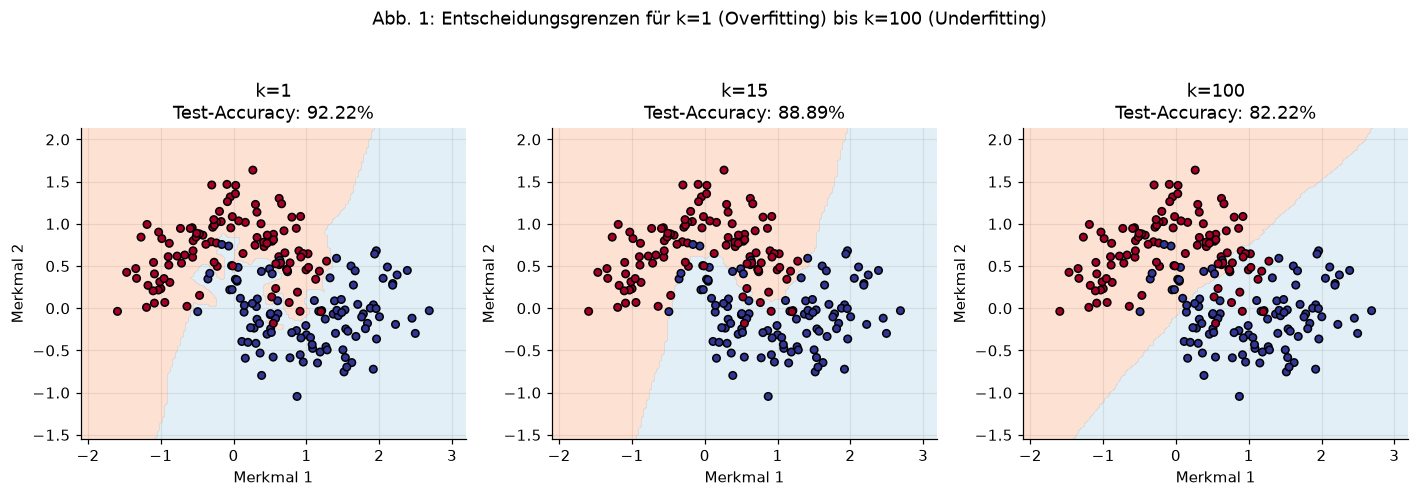

In [4]:
def plot_decision_boundary(model, X, y, title, ax):
    """Zeichnet die Entscheidungsgrenze eines Klassifikators mit .predict(X)."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="RdYlBu", s=24)
    ax.set_title(title)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")


def accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.3))
for k_val, ax in zip([1, 15, 100], axes):
    knn = KNearestNeighbors(k=k_val).fit(X_train, y_train)
    acc = accuracy(y_test, knn.predict(X_test))
    plot_decision_boundary(knn, X_train, y_train, f"k={k_val}\nTest-Accuracy: {acc:.2%}", ax)
fig.suptitle("Abb. 1: Entscheidungsgrenzen für k=1 (Overfitting) bis k=100 (Underfitting)", y=1.04)
plt.tight_layout()
plt.show()

**Interpretation.** Bei $k=1$ ist die Entscheidungsgrenze extrem zackig — jeder
Trainingspunkt definiert sein eigenes kleines Gebiet, das Modell hat null Bias auf den
Trainingsdaten, aber hohe Varianz (empfindlich gegenüber einzelnen Punkten, insbesondere
Ausreißern). Bei $k=100$ (nahe der Trainingsmenge-Größe) nähert sich die Grenze einer
Geraden an, ähnlich der linearen Entscheidungsgrenze aus Notebook 02 — hoher Bias, da
lokale Struktur verloren geht. $k=15$ liegt dazwischen und bildet die tatsächliche
Halbmond-Struktur ab, ohne dem Rauschen einzelner Punkte zu folgen.

### 5.2 Wahl von k über Kreuzvalidierung

Eine einzelne Testmenge ist zu klein, um $k$ verlässlich zu wählen (Notebook 01,
Abschnitt 7, Punkt 2). $K$-fache Kreuzvalidierung mittelt die Genauigkeit über $K$
Aufteilungen der Trainingsmenge und liefert ein Genauigkeitsintervall pro $k$.

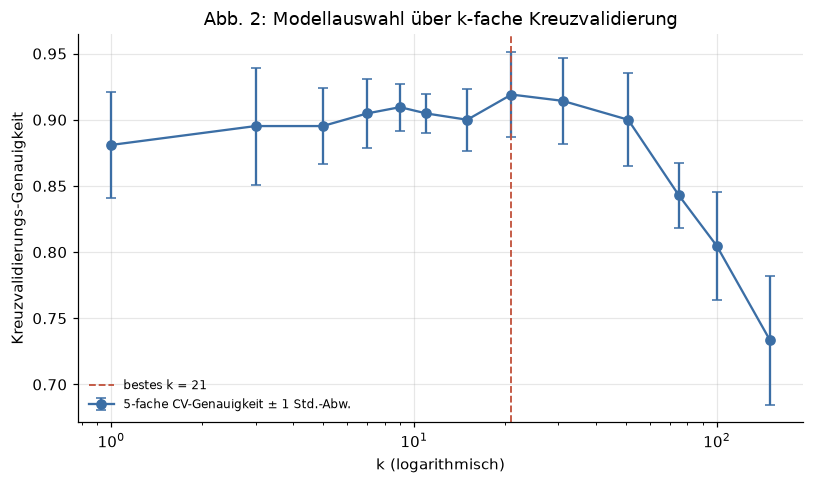

Bestes k nach 5-facher CV: 21


In [5]:
from sklearn.model_selection import StratifiedKFold

k_grid = np.array([1, 3, 5, 7, 9, 11, 15, 21, 31, 51, 75, 100, 150])
n_folds = 5
cv_scores = np.zeros((len(k_grid), n_folds))
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

for j, (fold_train_idx, fold_val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train[fold_train_idx], X_train[fold_val_idx]
    y_fold_train, y_fold_val = y_train[fold_train_idx], y_train[fold_val_idx]
    for i, k_val in enumerate(k_grid):
        knn = KNearestNeighbors(k=int(k_val)).fit(X_fold_train, y_fold_train)
        cv_scores[i, j] = accuracy(y_fold_val, knn.predict(X_fold_val))

mean_scores = cv_scores.mean(axis=1)
std_scores = cv_scores.std(axis=1)
best_k = int(k_grid[np.argmax(mean_scores)])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(k_grid, mean_scores, yerr=std_scores, fmt="o-", color="#3b6ea5",
            capsize=3, label=f"{n_folds}-fache CV-Genauigkeit ± 1 Std.-Abw.")
ax.axvline(best_k, color="#c1523d", ls="--", lw=1.2, label=f"bestes k = {best_k}")
ax.set_xscale("log")
ax.set_xlabel("k (logarithmisch)")
ax.set_ylabel("Kreuzvalidierungs-Genauigkeit")
ax.set_title("Abb. 2: Modellauswahl über k-fache Kreuzvalidierung")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Bestes k nach {n_folds}-facher CV: {best_k}")

Test-Accuracy mit k=21: 0.9000


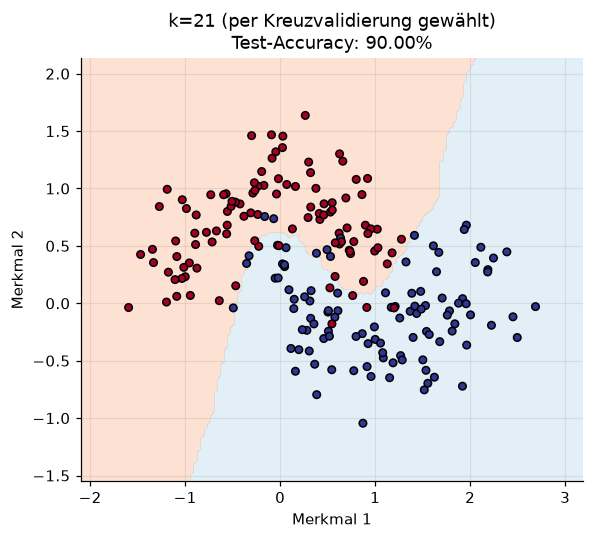

In [6]:
knn_best = KNearestNeighbors(k=best_k).fit(X_train, y_train)
test_acc_best = accuracy(y_test, knn_best.predict(X_test))
print(f"Test-Accuracy mit k={best_k}: {test_acc_best:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5.0))
plot_decision_boundary(knn_best, X_train, y_train,
                        f"k={best_k} (per Kreuzvalidierung gewählt)\nTest-Accuracy: {test_acc_best:.2%}", ax)
plt.tight_layout()
plt.show()

### 5.3 Der Fluch der Dimensionalität

Mit wachsender Dimensionalität $p$ wird der Trainingsraum bei festem $n$ zunehmend
dünn besetzt: Der erwartete Abstand zum nächsten Nachbarn wächst, und "nah" verliert
an Aussagekraft. Formal gilt für $n$ gleichverteilte Punkte im Einheitswürfel
$[0,1]^p$: Um einen Anteil $f$ des Volumens abzudecken, muss die Kantenlänge eines
Teilwürfels $e_p(f)=f^{1/p}$ betragen — bei $p=20$ und $f=0.01$ folgt bereits
$e_{20}(0.01)\approx 0.80$, also fast die gesamte Kantenlänge des Raums.

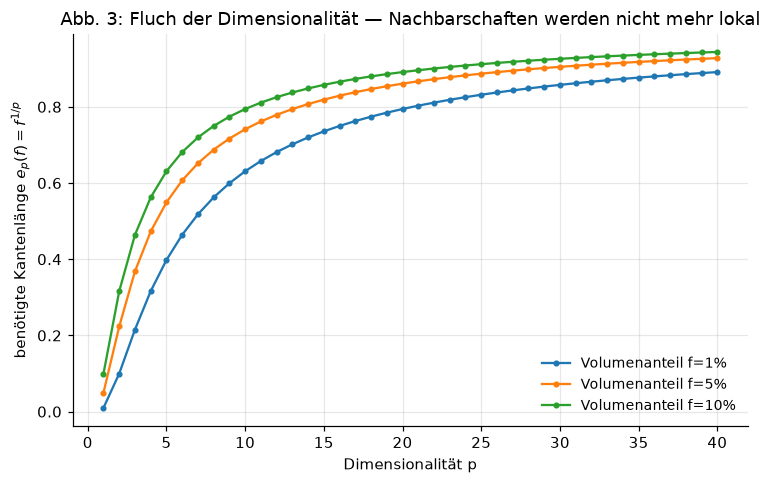

In [7]:
fractions = [0.01, 0.05, 0.10]
dims = np.arange(1, 41)

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for f in fractions:
    edge_length = f ** (1.0 / dims)
    ax.plot(dims, edge_length, "o-", ms=3, label=f"Volumenanteil f={f:.0%}")
ax.set_xlabel("Dimensionalität p")
ax.set_ylabel("benötigte Kantenlänge $e_p(f) = f^{1/p}$")
ax.set_title("Abb. 3: Fluch der Dimensionalität — Nachbarschaften werden nicht mehr lokal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

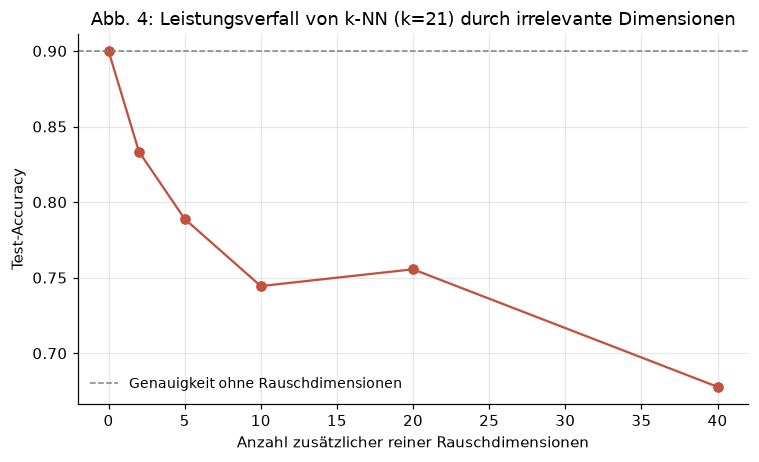

In [8]:
# Empirische Bestaetigung: Testgenauigkeit von k-NN bei wachsender Anzahl
# nutzloser (reiner Rausch-) Zusatzdimensionen, bei konstanter Stichprobengroesse.
n_noise_dims_grid = [0, 2, 5, 10, 20, 40]
acc_by_noise_dim = []

for n_noise in n_noise_dims_grid:
    gen = np.random.default_rng(RANDOM_STATE)
    noise_train = gen.normal(size=(len(X_train), n_noise))
    noise_test = gen.normal(size=(len(X_test), n_noise))
    X_train_aug = np.hstack([X_train, noise_train])
    X_test_aug = np.hstack([X_test, noise_test])

    knn_aug = KNearestNeighbors(k=best_k).fit(X_train_aug, y_train)
    acc_by_noise_dim.append(accuracy(y_test, knn_aug.predict(X_test_aug)))

fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(n_noise_dims_grid, acc_by_noise_dim, "o-", color="#c1523d")
ax.axhline(test_acc_best, color="gray", ls="--", lw=1, label="Genauigkeit ohne Rauschdimensionen")
ax.set_xlabel("Anzahl zusätzlicher reiner Rauschdimensionen")
ax.set_ylabel("Test-Accuracy")
ax.set_title(f"Abb. 4: Leistungsverfall von k-NN (k={best_k}) durch irrelevante Dimensionen")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** Ohne Rauschdimensionen liegt die Distanz vollständig in den beiden
informativen Merkmalen begründet. Mit jeder zusätzlichen Rauschdimension trägt ein
zunehmender, nutzloser Anteil zur Distanzberechnung bei; die "nächsten" Nachbarn nach
euklidischer Distanz sind zunehmend zufällig bezüglich der wahren Klassenstruktur, und
die Testgenauigkeit fällt spürbar. Das ist der praktische Kern des Fluchs der
Dimensionalität: k-NN benötigt bei hochdimensionalen, aber nur teilweise informativen
Merkmalsräumen eine vorgeschaltete Merkmalsauswahl oder -reduktion — etwa PCA
(Notebook 07).

### 5.4 Validierung gegen `scikit-learn`

In [9]:
from sklearn.neighbors import KNeighborsClassifier

reference = KNeighborsClassifier(n_neighbors=best_k, algorithm="brute", metric="euclidean")
reference.fit(X_train, y_train)

y_pred_own = knn_best.predict(X_test)
y_pred_ref = reference.predict(X_test)

agreement = float(np.mean(y_pred_own == y_pred_ref))
print(f"Übereinstimmung der Vorhersagen mit scikit-learn: {agreement:.2%} "
      f"({np.sum(y_pred_own != y_pred_ref)} von {len(y_test)} abweichend)")
print(f"Eigene Test-Accuracy:        {accuracy(y_test, y_pred_own):.4f}")
print(f"scikit-learn Test-Accuracy:  {accuracy(y_test, y_pred_ref):.4f}")

Übereinstimmung der Vorhersagen mit scikit-learn: 100.00% (0 von 90 abweichend)
Eigene Test-Accuracy:        0.9000
scikit-learn Test-Accuracy:  0.9000


**Interpretation.** Abweichungen entstehen ausschließlich bei Distanz-Gleichständen
(mehrere Punkte mit identischer Distanz an der $k$-ten Position), bei denen `NumPy`s
`argpartition` und `scikit-learn`s Baumsuche unterschiedliche, aber gleichermaßen
gültige Nachbarn auswählen können — die Klassifikationsregel selbst ist identisch.

<a id="6"></a>
## 6 Diskussion und Grenzen

**Ergebnis.** k-NN bildet die nicht-lineare Halbmond-Struktur ohne funktionale Annahme
ab; die per Kreuzvalidierung gewählte Nachbarschaftsgröße $k$ balanciert Bias und
Varianz sichtbar besser als beliebig gewählte Extremwerte. Der Fluch der
Dimensionalität begrenzt den Ansatz jedoch fundamental bei vielen Merkmalen.

**Methodische Einschränkungen.**

1. *Skalensensitivität.* Ohne Standardisierung dominieren Merkmale mit großem
   Wertebereich die Distanzberechnung (Abschnitt 1.3).
2. *Rechenkosten zur Vorhersagezeit.* Anders als bei den parametrischen Modellen
   (Notebooks 01, 02) wächst der Vorhersageaufwand mit $n$ — bei sehr großen
   Datensätzen ohne Baumstrukturen unpraktikabel.
3. *Fluch der Dimensionalität.* Bei vielen (insbesondere irrelevanten) Merkmalen
   verlieren Distanzen an Trennschärfe (Abschnitt 5.3).
4. *Unbalancierte Klassen.* Bei stark unbalancierten Klassen dominiert die
   Mehrheitsklasse die Nachbarschaft unabhängig vom tatsächlich nächsten Punkt;
   distanzgewichtete Abstimmung (Übungsaufgabe 3) mildert dies teilweise.

**Anschluss.** Notebook 04 betrachtet mit dem Entscheidungsbaum ein weiteres
nicht-parametrisches Modell, das im Gegensatz zu k-NN explizit interpretierbare Regeln
erzeugt.

<a id="7"></a>
## 7 Übungsaufgaben

1. **Skaleneffekt.** Multiplizieren Sie ein Merkmal mit dem Faktor 100 und wiederholen
   Sie Abschnitt 5.1 ohne Standardisierung. Wie verändert sich die Entscheidungsgrenze?
2. **Manhattan- vs. euklidische Distanz.** Wiederholen Sie die Kreuzvalidierung aus
   Abschnitt 5.2 mit `metric="manhattan"`. Unterscheidet sich das optimale $k$?
3. **Distanzgewichtete Abstimmung.** Erweitern Sie `predict`, sodass jeder Nachbar mit
   Gewicht $1/d(\mathbf{x},\mathbf{x}_i)$ statt gleichgewichtet in die
   Mehrheitsentscheidung eingeht. Vergleichen Sie die Entscheidungsgrenze bei $k=100$
   mit und ohne Gewichtung.
4. **Rechenzeit.** Messen Sie die Vorhersagezeit der Eigenimplementierung für
   $n\in\{200, 2000, 20000\}$ Trainingspunkte (synthetisch erzeugt) und vergleichen Sie
   das empirische Skalierungsverhalten mit der in Abschnitt 1.4 angegebenen Komplexität.
5. **Dimensionsreduktion vor k-NN.** Wenden Sie PCA (Notebook 07) auf die
   Rausch-augmentierten Daten aus Abschnitt 5.3 an, bevor Sie k-NN anwenden. Kann der
   Leistungsverlust rückgängig gemacht werden?

<a id="8"></a>
## 8 Literatur

* Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE
  Transactions on Information Theory*, 13(1), 21–27.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning* (2. Aufl.). Springer. Kap. 2 und 13.
* Bellman, R. (1961). *Adaptive Control Processes: A Guided Tour*. Princeton
  University Press.